# The Screening Clinic
## Build a useful model, not just an accurate one

You are joining a fictional clinic for two tasks:

1. Predict a patient's **recovery time in days** with linear regression.
2. Predict whether a patient needs **follow-up testing** with logistic regression.

### What you will build

You will implement the important machine-learning pieces directly with NumPy:

- linear regression, MSE, and gradient descent;
- sigmoid, logistic regression, and binary cross-entropy;
- confusion-matrix metrics;
- a separate decision threshold trained with weighted perceptron updates;
- an honest comparison between training loss and one untouched final test set.

## 0. Setup and story

Run the imports and supplied data-generation code.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.precision", 3)

COLORS = {
    "data": "#4C78A8",
    "model": "#F58518",
    "positive": "#E45756",
    "negative": "#54A24B",
    "validation": "#B279A2",
}

def make_recovery_data(n=420):
    """Create synthetic patient data for the recovery-time task."""
    rng = np.random.default_rng()
    symptom_severity = rng.uniform(0, 10, n)
    age = np.clip(rng.normal(48, 17, n), 18, 88)
    biomarker_level = np.clip(
        3.0 + 0.75 * symptom_severity + 0.035 * (age - 48)
        + rng.normal(0, 1.6, n),
        0.1,
        None,
    )
    recovery_days = (
        2.5
        + 1.65 * symptom_severity
        + 0.045 * (age - 48)
        + 0.22 * biomarker_level
        + rng.normal(0, 2.0, n)
    )
    recovery_days = np.clip(recovery_days, 1.0, None)
    return pd.DataFrame({
        "symptom_severity": symptom_severity,
        "age": age,
        "biomarker_level": biomarker_level,
        "recovery_days": recovery_days,
    })

recovery_df = make_recovery_data()
display(recovery_df.head())
print("Recovery dataset shape:", recovery_df.shape)

,symptom_severity,age,biomarker_level,recovery_days
0,0.754,53.960,0.630,3.435
1,3.632,65.969,6.169,10.311
2,1.963,50.345,5.675,7.352
3,5.075,59.301,6.192,12.731
4,4.036,52.073,5.210,8.653


Recovery dataset shape: (420, 4)


### Data dictionary

| Column | Meaning |
|---|---|
| symptom_severity | Synthetic score from 0 to 10 |
| age | Patient age in years |
| biomarker_level | Synthetic lab measurement |
| recovery_days | Number of days until recovery; the regression target |

**Before continuing:** Which column is the target? Which columns could be useful inputs?

## 1. Linear regression with one feature

We begin with only **symptom severity**. One input feature lets us draw every patient as a point and the model as a line.

A linear model computes:

    prediction = X @ weights + bias

For one feature, the weight controls the line's slope and the bias moves the line up or down.

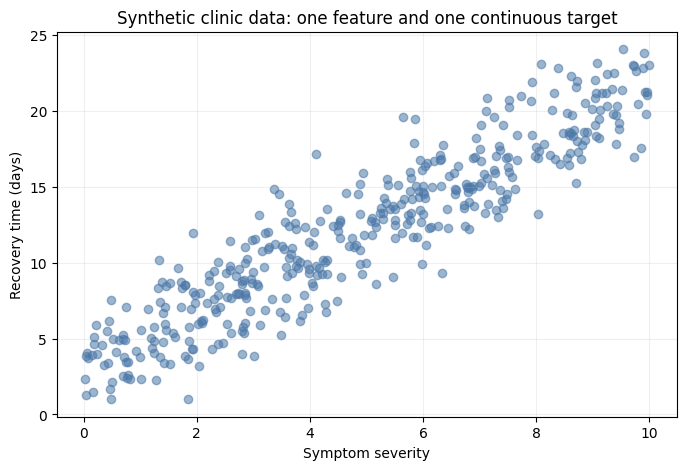

In [2]:
plt.figure(figsize=(8, 5))
plt.scatter(
    recovery_df["symptom_severity"],
    recovery_df["recovery_days"],
    alpha=0.55,
    color=COLORS["data"],
)
plt.xlabel("Symptom severity")
plt.ylabel("Recovery time (days)")
plt.title("Synthetic clinic data: one feature and one continuous target")
plt.grid(alpha=0.2)
plt.show()

### TODO 1 — implement the linear forward pass

Use NumPy matrix multiplication. Your function must work for one feature or many features.

Expected shapes:

- X: (number of rows, number of features)
- weights: (number of features,)
- result: (number of rows,)

In [3]:
def linear_predict(X, weights, bias):
    """Return one prediction per row of X."""
    # NEW CODE
    return X @ weights + bias
    # END OF NEW CODE


_tiny_X = np.array([[1.0], [2.0], [3.0]])
_tiny_w = np.array([2.0])
assert np.allclose(linear_predict(_tiny_X, _tiny_w, 1.0), [3.0, 5.0, 7.0])
print("Linear forward-pass checks passed.")

Linear forward-pass checks passed.


### Adjust a line by hand

Try changing manual_weight and manual_bias. Do not aim for perfection; use the graph to understand what each parameter does.

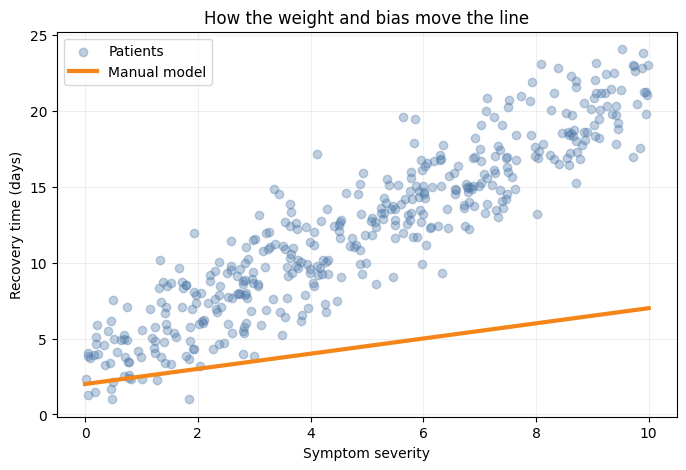

In [4]:
X_one_raw = recovery_df[["symptom_severity"]].to_numpy()
y_recovery = recovery_df["recovery_days"].to_numpy()

manual_weight = np.array([0.5])
manual_bias = 2.0

severity_grid = np.linspace(0, 10, 200).reshape(-1, 1)
manual_line = linear_predict(severity_grid, manual_weight, manual_bias)

plt.figure(figsize=(8, 5))
plt.scatter(
    X_one_raw[:, 0], y_recovery,
    alpha=0.35, color=COLORS["data"], label="Patients",
)
plt.plot(
    severity_grid[:, 0], manual_line,
    color=COLORS["model"], linewidth=3, label="Manual model",
)
plt.xlabel("Symptom severity")
plt.ylabel("Recovery time (days)")
plt.title("How the weight and bias move the line")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

> **Reflection**
>
> 1. What happens when you increase the weight?
> 2. What happens when you increase only the bias?
> 3. Why would adjusting parameters by hand become difficult with several features?

## 2. Train linear regression from zero

Hand-tuning does not scale. We need a loss, gradients, and a learning rate.

Mean-squared error (MSE) squares every prediction error and then takes the average.

In [5]:
def random_train_eval_indices(n_rows, train_fraction=0.80):
    """Supplied NumPy-only split helper."""
    rng = np.random.default_rng()
    indices = rng.permutation(n_rows)
    cut = int(train_fraction * n_rows)
    return indices[:cut], indices[cut:]

reg_train_idx, reg_eval_idx = random_train_eval_indices(len(recovery_df))
X_reg_raw = recovery_df[["symptom_severity"]].to_numpy()
y_reg = recovery_df["recovery_days"].to_numpy()

reg_mean = X_reg_raw[reg_train_idx].mean(axis=0)
reg_std = X_reg_raw[reg_train_idx].std(axis=0)
reg_std = np.where(reg_std == 0, 1.0, reg_std)

X_reg_train = (X_reg_raw[reg_train_idx] - reg_mean) / reg_std
X_reg_eval = (X_reg_raw[reg_eval_idx] - reg_mean) / reg_std
y_reg_train = y_reg[reg_train_idx]
y_reg_eval = y_reg[reg_eval_idx]

print("Training rows:", len(reg_train_idx))
print("Held-out evaluation rows:", len(reg_eval_idx))

Training rows: 336
Held-out evaluation rows: 84


### TODO 2 — implement MSE

Calculate prediction minus true value, square it, and return the average.

In [6]:
def mse(y_true, y_pred):
    """Mean-squared error."""
    # NEW CODE
    errors = y_pred - y_true
    return np.mean(errors ** 2)
    # END OF NEW CODE


assert np.isclose(mse(np.array([1.0, 2.0]), np.array([1.0, 2.0])), 0.0)
assert np.isclose(mse(np.array([1.0, 3.0]), np.array([0.0, 0.0])), 5.0)
print("MSE checks passed.")

MSE checks passed.


### TODO 3 — implement the linear gradients

The formulas are supplied:

- error = prediction - true value
- weight gradient = 2 times the average of X multiplied by error
- bias gradient = 2 times the average error

<details>
<summary>Shape hint</summary>

X.T @ error produces one gradient value per feature.
</details>

In [7]:
def linear_gradients(X, y_true, y_pred):
    """Return (weight_gradient, bias_gradient) for MSE."""
    # NEW CODE
    errors = y_pred - y_true
    weight_gradient = 2.0 * (X.T @ errors) / len(y_true)
    bias_gradient = 2.0 * np.mean(errors)
    return weight_gradient, bias_gradient
    # END OF NEW CODE


def check_linear_gradients():
    X = np.array([[-1.0], [0.5], [2.0]])
    y = np.array([1.0, 2.0, 4.0])
    w = np.array([0.3])
    b = 0.2
    pred = linear_predict(X, w, b)
    dw, db = linear_gradients(X, y, pred)

    eps = 1e-6
    numeric_dw = (
        mse(y, linear_predict(X, w + eps, b))
        - mse(y, linear_predict(X, w - eps, b))
    ) / (2 * eps)
    numeric_db = (
        mse(y, linear_predict(X, w, b + eps))
        - mse(y, linear_predict(X, w, b - eps))
    ) / (2 * eps)

    assert np.allclose(dw, [numeric_dw], atol=1e-5)
    assert np.isclose(db, numeric_db, atol=1e-5)
    print("Linear-gradient checks passed.")

check_linear_gradients()

Linear-gradient checks passed.


### TODO 4 — assemble gradient descent

Inside each step: predict, measure loss, compute gradients, and subtract learning rate times gradient from each parameter.

In [8]:
def train_linear(X, y, learning_rate=0.05, n_steps=400):
    """Train linear regression with full-batch gradient descent."""
    weights = np.zeros(X.shape[1], dtype=float)
    bias = 0.0
    loss_history = []

    for step in range(n_steps):
        # NEW CODE
        predictions = linear_predict(X, weights, bias)
        loss_history.append(mse(y, predictions))
        dw, db = linear_gradients(X, y, predictions)
        weights = weights - learning_rate * dw
        bias = bias - learning_rate * db
        # END OF NEW CODE

    return weights, bias, np.asarray(loss_history)

### Fit the model and evaluate on unseen patients

Training RMSE: 2.03 days
Held-out RMSE: 2.32 days


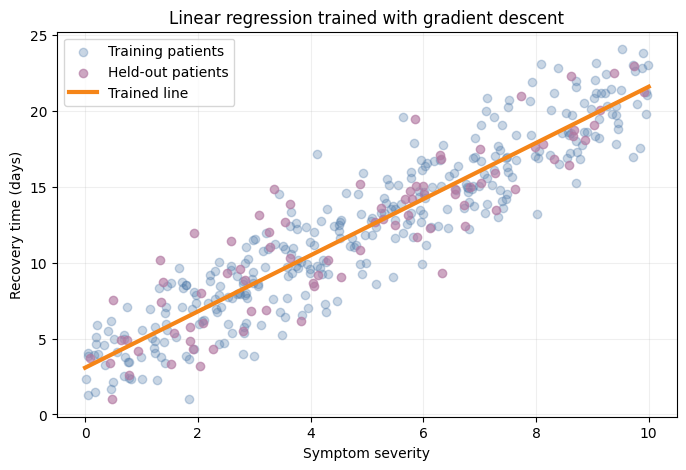

In [9]:
reg_weights, reg_bias, reg_loss_history = train_linear(
    X_reg_train, y_reg_train, learning_rate=0.05, n_steps=400,
)

train_reg_pred = linear_predict(X_reg_train, reg_weights, reg_bias)
eval_reg_pred = linear_predict(X_reg_eval, reg_weights, reg_bias)

print(f"Training RMSE: {np.sqrt(mse(y_reg_train, train_reg_pred)):.2f} days")
print(f"Held-out RMSE: {np.sqrt(mse(y_reg_eval, eval_reg_pred)):.2f} days")

raw_grid = np.linspace(0, 10, 200).reshape(-1, 1)
scaled_grid = (raw_grid - reg_mean) / reg_std
fitted_line = linear_predict(scaled_grid, reg_weights, reg_bias)

plt.figure(figsize=(8, 5))
plt.scatter(X_reg_raw[reg_train_idx, 0], y_reg_train, alpha=0.3,
            color=COLORS["data"], label="Training patients")
plt.scatter(X_reg_raw[reg_eval_idx, 0], y_reg_eval, alpha=0.65,
            color=COLORS["validation"], label="Held-out patients")
plt.plot(raw_grid[:, 0], fitted_line, color=COLORS["model"],
         linewidth=3, label="Trained line")
plt.xlabel("Symptom severity")
plt.ylabel("Recovery time (days)")
plt.title("Linear regression trained with gradient descent")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

### Learning-rate experiment

Train the same model with a tiny, useful, and unstable rate.

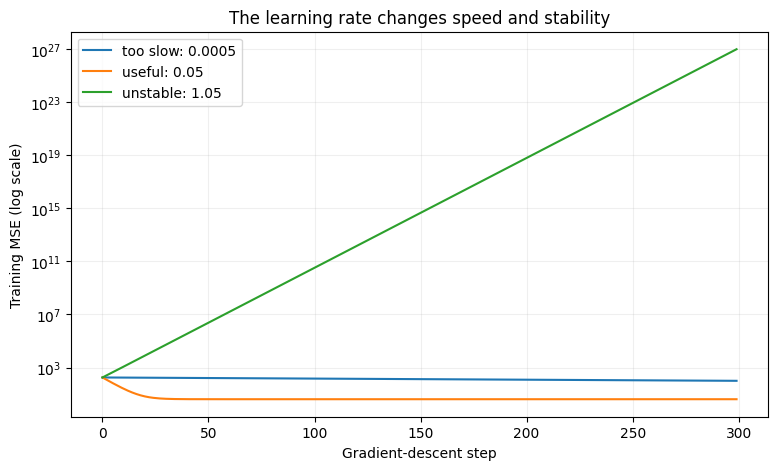

In [10]:
linear_rate_experiments = {
    "too slow: 0.0005": 0.0005,
    "useful: 0.05": 0.05,
    "unstable: 1.05": 1.05,
}

plt.figure(figsize=(9, 5))
for label, rate in linear_rate_experiments.items():
    _, _, loss_history = train_linear(
        X_reg_train, y_reg_train, learning_rate=rate, n_steps=300,
    )
    plt.plot(loss_history, label=label)

plt.yscale("log")
plt.xlabel("Gradient-descent step")
plt.ylabel("Training MSE (log scale)")
plt.title("The learning rate changes speed and stability")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

### Use several features

The algorithm does not change. Only the number of columns in X changes.

In [11]:
MULTI_FEATURES = ["symptom_severity", "age", "biomarker_level"]
X_multi_raw = recovery_df[MULTI_FEATURES].to_numpy()

multi_mean = X_multi_raw[reg_train_idx].mean(axis=0)
multi_std = X_multi_raw[reg_train_idx].std(axis=0)
multi_std = np.where(multi_std == 0, 1.0, multi_std)

X_multi_train = (X_multi_raw[reg_train_idx] - multi_mean) / multi_std
X_multi_eval = (X_multi_raw[reg_eval_idx] - multi_mean) / multi_std

multi_w, multi_b, _ = train_linear(
    X_multi_train, y_reg_train, learning_rate=0.05, n_steps=400,
)
multi_eval_pred = linear_predict(X_multi_eval, multi_w, multi_b)

display(pd.DataFrame({
    "model": ["one feature", "three features"],
    "held_out_RMSE_days": [
        np.sqrt(mse(y_reg_eval, eval_reg_pred)),
        np.sqrt(mse(y_reg_eval, multi_eval_pred)),
    ],
}))

,model,held_out_RMSE_days
0,one feature,2.325
1,three features,2.133


> **Reflection**
>
> 1. Why did we calculate scaling values from training rows only?
> 2. Which learning-rate curve looks healthiest?
> 3. Did extra features improve held-out RMSE?

## 3. From recovery time to individual probabilities

Logistic regression reuses X @ weights + bias, then applies a sigmoid so the result stays between 0 and 1.

In [12]:
def make_diagnosis_data(n=3000, positive_rate=0.08):
    """Create an imbalanced synthetic diagnosis dataset."""
    rng = np.random.default_rng()
    n_positive = int(round(n * positive_rate))
    y = np.zeros(n, dtype=int)
    y[:n_positive] = 1
    rng.shuffle(y)

    age = np.clip(rng.normal(44 + 8 * y, 15, n), 18, 90)
    symptom_severity = np.clip(rng.normal(2.2 + 3.0 * y, 1.45, n), 0, 10)
    biomarker_level = np.clip(rng.normal(4.0 + 4.1 * y, 1.9, n), 0.1, None)
    heart_rate = np.clip(
        rng.normal(70 + 1.1 * symptom_severity + 6.0 * y, 8.5, n),
        45, 140,
    )
    noise_measurement = rng.normal(0, 1, n)

    return pd.DataFrame({
        "age": age,
        "symptom_severity": symptom_severity,
        "biomarker_level": biomarker_level,
        "heart_rate": heart_rate,
        "noise_measurement": noise_measurement,
        "needs_follow_up": y,
    })

def stratified_three_way_split(y, train_fraction=0.70,
                               validation_fraction=0.15):
    """Supplied NumPy-only stratified train/validation/test split."""
    rng = np.random.default_rng()
    train_parts, validation_parts, test_parts = [], [], []
    for label in np.unique(y):
        label_indices = np.flatnonzero(y == label)
        rng.shuffle(label_indices)
        n_train = int(train_fraction * len(label_indices))
        n_validation = int(validation_fraction * len(label_indices))
        train_parts.append(label_indices[:n_train])
        validation_parts.append(label_indices[n_train:n_train + n_validation])
        test_parts.append(label_indices[n_train + n_validation:])

    train_idx = np.concatenate(train_parts)
    validation_idx = np.concatenate(validation_parts)
    test_idx = np.concatenate(test_parts)
    rng.shuffle(train_idx)
    rng.shuffle(validation_idx)
    rng.shuffle(test_idx)
    return train_idx, validation_idx, test_idx

diagnosis_df = make_diagnosis_data()
CLASS_FEATURES = ["age", "symptom_severity", "biomarker_level",
                  "heart_rate", "noise_measurement"]

X_class_raw = diagnosis_df[CLASS_FEATURES].to_numpy()
y_class = diagnosis_df["needs_follow_up"].to_numpy()
class_train_idx, class_validation_idx, class_test_idx = (
    stratified_three_way_split(y_class)
)

class_mean = X_class_raw[class_train_idx].mean(axis=0)
class_std = X_class_raw[class_train_idx].std(axis=0)
class_std = np.where(class_std == 0, 1.0, class_std)

X_class_train = (X_class_raw[class_train_idx] - class_mean) / class_std
X_class_validation = (X_class_raw[class_validation_idx] - class_mean) / class_std
X_class_test = (X_class_raw[class_test_idx] - class_mean) / class_std
y_class_train = y_class[class_train_idx]
y_class_validation = y_class[class_validation_idx]
y_class_test = y_class[class_test_idx]

display(diagnosis_df.head())
print("Train / validation / test sizes:",
      len(class_train_idx), len(class_validation_idx), len(class_test_idx))
print(f"Positive rate in training data: {y_class_train.mean():.1%}")
print("The test labels now remain untouched until Section 6.")

,age,symptom_severity,biomarker_level,heart_rate,noise_measurement,needs_follow_up
0,48.686,2.120,0.816,79.065,0.418,0
1,63.780,1.769,5.071,65.373,1.701,0
2,59.956,6.071,7.654,85.534,-0.839,1
3,18.000,2.161,4.543,66.831,0.528,0
4,55.504,0.638,4.317,78.343,0.066,0


Train / validation / test sizes: 2099 450 451
Positive rate in training data: 8.0%
The test labels now remain untouched until Section 6.


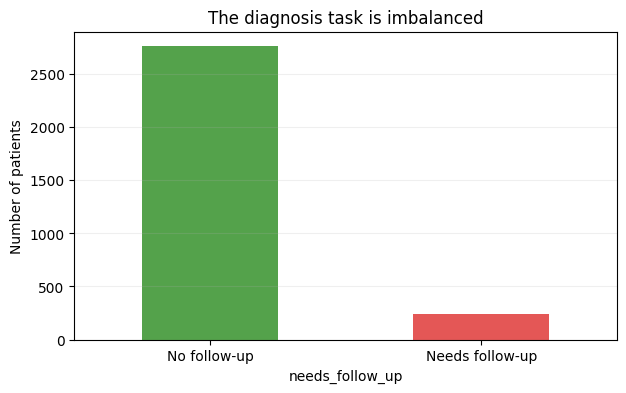

In [13]:
diagnosis_df["needs_follow_up"].value_counts().sort_index().rename(
    index={0: "No follow-up", 1: "Needs follow-up"}
).plot(kind="bar", color=[COLORS["negative"], COLORS["positive"]],
       figsize=(7, 4))
plt.ylabel("Number of patients")
plt.title("The diagnosis task is imbalanced")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.2)
plt.show()

### TODO 5 — implement the sigmoid

Calculate:

    1 / (1 + exp(-score))


In [14]:
def sigmoid(scores):
    """Map linear scores to values between 0 and 1."""
    # NEW CODE
    return 1.0 / (1.0 + np.exp(-scores))
    # END OF NEW CODE


_example_scores = np.array([-4.0, -2.0, 0.0, 2.0, 4.0])
_example_probabilities = sigmoid(_example_scores)
assert np.isclose(_example_probabilities[2], 0.5)
assert np.all((_example_probabilities >= 0) & (_example_probabilities <= 1))
display(pd.DataFrame({
    "linear_score": _example_scores,
    "sigmoid_output": _example_probabilities,
}))

,linear_score,sigmoid_output
0,-4.0,0.018
1,-2.0,0.119
2,0.0,0.500
3,2.0,0.881
4,4.0,0.982


### A threshold turns probabilities into decisions

The threshold is a separate decision rule. Later, you will train it while keeping the model fixed.

In [15]:
example_probabilities = np.array([0.05, 0.25, 0.49, 0.50, 0.72, 0.95])
for threshold in [0.25, 0.50, 0.75]:
    decisions = (example_probabilities >= threshold).astype(int)
    print(f"threshold={threshold:.2f} -> {decisions}")

threshold=0.25 -> [0 1 1 1 1 1]
threshold=0.50 -> [0 0 0 1 1 1]
threshold=0.75 -> [0 0 0 0 0 1]


> **Reflection**
>
> 1. Which part of logistic regression is still linear?
> 2. What information would be lost if the model returned only 0 or 1?
> 3. Does changing the threshold retrain the model weights?

## 4. Train logistic regression from zero

For a binary target, binary cross-entropy (BCE) strongly penalizes a model that is confidently wrong.

### TODO 6 — implement BCE

Calculate each patient's BCE and return the average:

    -(y * log(probability) + (1 - y) * log(1 - probability))

The probabilities produced in this exercise stay between 0 and 1 without reaching either endpoint.


In [16]:
def binary_cross_entropy(y_true, probabilities):
    """Average binary cross-entropy."""
    # NEW CODE
    patient_losses = -(
        y_true * np.log(probabilities)
        + (1 - y_true) * np.log(1.0 - probabilities)
    )
    return np.mean(patient_losses)
    # END OF NEW CODE


assert binary_cross_entropy(
    np.array([0, 1]), np.array([0.1, 0.9])
) < binary_cross_entropy(
    np.array([0, 1]), np.array([0.4, 0.6])
)
print("BCE checks passed.")

BCE checks passed.


### TODO 7 — implement logistic gradients

- error = probability - true label
- weight gradient = average of X multiplied by error
- bias gradient = average error

In [17]:
def logistic_gradients(X, y_true, probabilities):
    """Return (weight_gradient, bias_gradient) for sigmoid + BCE."""
    # NEW CODE
    errors = probabilities - y_true
    weight_gradient = (X.T @ errors) / len(y_true)
    bias_gradient = np.mean(errors)
    return weight_gradient, bias_gradient
    # END OF NEW CODE


def check_logistic_gradients():
    X = np.array([[-1.0, 0.2], [0.5, 1.0], [2.0, -0.5]])
    y = np.array([0.0, 1.0, 1.0])
    w = np.array([0.1, -0.2])
    b = 0.05
    probabilities = sigmoid(linear_predict(X, w, b))
    dw, db = logistic_gradients(X, y, probabilities)

    eps = 1e-6
    numeric_dw = np.zeros_like(w)
    for j in range(len(w)):
        step = np.zeros_like(w)
        step[j] = eps
        loss_plus = binary_cross_entropy(
            y, sigmoid(linear_predict(X, w + step, b))
        )
        loss_minus = binary_cross_entropy(
            y, sigmoid(linear_predict(X, w - step, b))
        )
        numeric_dw[j] = (loss_plus - loss_minus) / (2 * eps)

    numeric_db = (
        binary_cross_entropy(y, sigmoid(linear_predict(X, w, b + eps)))
        - binary_cross_entropy(y, sigmoid(linear_predict(X, w, b - eps)))
    ) / (2 * eps)

    assert np.allclose(dw, numeric_dw, atol=1e-5)
    assert np.isclose(db, numeric_db, atol=1e-5)
    print("Logistic-gradient checks passed.")

check_logistic_gradients()

Logistic-gradient checks passed.


### TODO 8 — assemble logistic gradient descent

Record training and validation loss, but update weights using training data only.

In [18]:
def train_logistic(
    X, y, learning_rate=0.08, n_steps=800,
    X_validation=None, y_validation=None,
):
    """Train logistic regression with full-batch gradient descent."""
    weights = np.zeros(X.shape[1], dtype=float)
    bias = 0.0
    train_loss_history = []
    validation_loss_history = []

    for step in range(n_steps):
        # NEW CODE
        train_probabilities = sigmoid(linear_predict(X, weights, bias))
        train_loss_history.append(
            binary_cross_entropy(y, train_probabilities)
        )

        if X_validation is not None and y_validation is not None:
            validation_probabilities = sigmoid(
                linear_predict(X_validation, weights, bias)
            )
            validation_loss_history.append(
                binary_cross_entropy(y_validation, validation_probabilities)
            )

        dw, db = logistic_gradients(X, y, train_probabilities)
        weights = weights - learning_rate * dw
        bias = bias - learning_rate * db
        # END OF NEW CODE

    loss_history = {
        "train_loss": np.asarray(train_loss_history),
        "validation_loss": np.asarray(validation_loss_history),
    }
    return weights, bias, loss_history

### Train the original model

This model uses ordinary BCE. Part 5 freezes its weights and trains only the decision threshold.

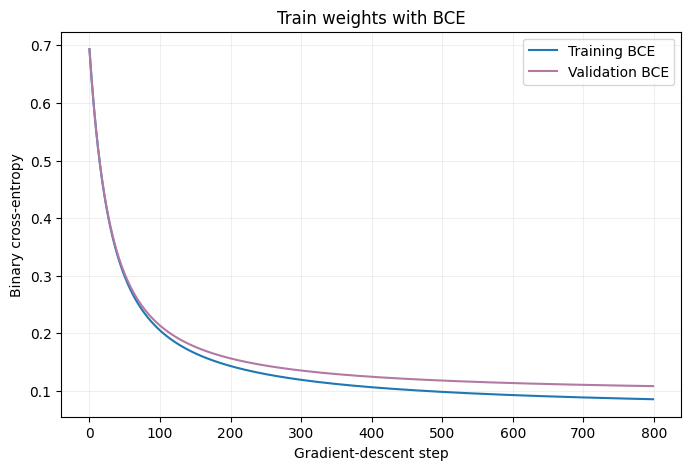

The original model is trained. Its weights are now frozen for Part 5.


In [19]:
original_weights, original_bias, original_loss_history = train_logistic(
    X_class_train, y_class_train,
    learning_rate=0.08, n_steps=800,
    X_validation=X_class_validation,
    y_validation=y_class_validation,
)

plt.figure(figsize=(8, 5))
plt.plot(original_loss_history["train_loss"], label="Training BCE")
plt.plot(original_loss_history["validation_loss"], label="Validation BCE",
         color=COLORS["validation"])
plt.xlabel("Gradient-descent step")
plt.ylabel("Binary cross-entropy")
plt.title("Train weights with BCE")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

validation_probabilities = sigmoid(
    linear_predict(X_class_validation, original_weights, original_bias)
)
print("The original model is trained. Its weights are now frozen for Part 5.")

> **Reflection**
>
> 1. What parts of train_linear and train_logistic are the same?
> 2. Why use BCE instead of accuracy to update weights?
> 3. Is validation loss used to calculate gradients?

## 5. The accuracy trap and threshold training

A model predicting 0 for everyone gets about 92% accuracy—but finds no sick patients.

### TODO 9 — implement confusion counts and metrics

Return 0 when a metric's denominator is zero.

In [20]:
def confusion_counts(y_true, y_pred):
    """Return tp, fp, fn, tn as integers."""
    # NEW CODE
    tp = int(np.sum((y_true == 1) & (y_pred == 1)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))
    tn = int(np.sum((y_true == 0) & (y_pred == 0)))
    return tp, fp, fn, tn
    # END OF NEW CODE


def safe_divide(numerator, denominator):
    return numerator / denominator if denominator != 0 else 0.0


def classification_metrics(y_true, y_pred):
    """Return accuracy, precision, recall, F1, and F2."""
    # NEW CODE
    tp, fp, fn, tn = confusion_counts(y_true, y_pred)
    accuracy = safe_divide(tp + tn, tp + fp + fn + tn)
    precision = safe_divide(tp, tp + fp)
    recall = safe_divide(tp, tp + fn)
    f1 = safe_divide(2.0 * precision * recall, precision + recall)
    f2 = safe_divide(5.0 * precision * recall, 4.0 * precision + recall)
    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "f2": f2,
    }
    # END OF NEW CODE


_metric_test_y = np.array([1, 1, 1, 0, 0, 0])
_metric_test_pred = np.array([1, 1, 0, 1, 0, 0])
assert confusion_counts(_metric_test_y, _metric_test_pred) == (2, 1, 1, 2)
_metric_test_result = classification_metrics(_metric_test_y, _metric_test_pred)
assert np.isclose(_metric_test_result["accuracy"], 4 / 6)
assert np.isclose(_metric_test_result["precision"], 2 / 3)
assert np.isclose(_metric_test_result["recall"], 2 / 3)
print("Metric checks passed.")

Metric checks passed.


In [21]:
def scorecard_row(name, y_true, y_pred):
    row = {"model": name}
    row.update(classification_metrics(y_true, y_pred))
    return row

always_negative_validation = np.zeros_like(y_class_validation)
default_validation_predictions = (validation_probabilities >= 0.5).astype(int)

display(pd.DataFrame([
    scorecard_row("Always predict no follow-up",
                  y_class_validation, always_negative_validation),
    scorecard_row("Logistic model, threshold 0.50",
                  y_class_validation, default_validation_predictions),
]))

print("Always-negative accuracy:",
      f"{classification_metrics(y_class_validation, always_negative_validation)['accuracy']:.1%}")
print("Always-negative recall:",
      f"{classification_metrics(y_class_validation, always_negative_validation)['recall']:.1%}")

,model,accuracy,precision,recall,f1,f2
0,Always predict no follow-up,0.920,0.000,0.000,0.00,0.000
1,"Logistic model, threshold 0.50",0.962,0.852,0.639,0.73,0.673


Always-negative accuracy: 92.0%
Always-negative recall: 0.0%


### Train a separate threshold with a perceptron-style rule

Illustrative costs:

- false negative: 12
- false positive: 1

Keep the logistic model's weights frozen. Its validation probabilities become the one-dimensional input to a **separate threshold classifier**:

    predict follow-up when probability >= threshold

This time, really train the threshold over several epochs. Use the perceptron's mistake-driven idea:

- for a false negative, lower the threshold by `learning_rate * false_negative_cost`;
- for a false positive, raise the threshold by `learning_rate * false_positive_cost`;
- for a correct decision, make no update.

The larger false-negative update expresses the clinic's priorities. Record the threshold and asymmetric loss after every epoch, and retain the threshold with the lowest validation loss seen during training.

> **Important distinction:** logistic regression itself **is differentiable**—Section 4 trained it with gradients. The hard comparison `probability >= threshold` and the resulting false-positive/false-negative counts are not differentiable with respect to the threshold. Therefore ordinary gradient descent cannot directly minimize this exact decision loss. A smooth substitute could be designed, but here we use the perceptron's mistake-driven updates to train the hard decision boundary directly.

    decision loss = (12 * FN + 1 * FP) / number of patients


In [22]:
FALSE_NEGATIVE_COST = 12.0
FALSE_POSITIVE_COST = 1.0

def asymmetric_decision_loss(
    y_true, y_pred,
    false_negative_cost=FALSE_NEGATIVE_COST,
    false_positive_cost=FALSE_POSITIVE_COST,
):
    """Average cost of false-negative and false-positive decisions."""
    # NEW CODE
    _, fp, fn, _ = confusion_counts(y_true, y_pred)
    total_cost = false_negative_cost * fn + false_positive_cost * fp
    return total_cost / len(y_true)
    # END OF NEW CODE


def train_threshold_perceptron(
    y_true, probabilities,
    initial_threshold=0.50,
    learning_rate=0.001,
    n_epochs=80,
    false_negative_cost=FALSE_NEGATIVE_COST,
    false_positive_cost=FALSE_POSITIVE_COST,
):
    """Train a hard probability threshold with weighted perceptron updates."""
    threshold = float(initial_threshold)
    threshold_history = []
    loss_history = []

    initial_predictions = (probabilities >= threshold).astype(int)
    best_threshold = threshold
    best_loss = asymmetric_decision_loss(
        y_true, initial_predictions,
        false_negative_cost, false_positive_cost,
    )

    for epoch in range(n_epochs):
        for true_label, probability in zip(y_true, probabilities):
            # NEW CODE
            prediction = int(probability >= threshold)
            if true_label == 1 and prediction == 0:
                threshold = (
                    threshold - learning_rate * false_negative_cost
                )
            elif true_label == 0 and prediction == 1:
                threshold = (
                    threshold + learning_rate * false_positive_cost
                )
            # END OF NEW CODE

        # NEW CODE
        epoch_predictions = (probabilities >= threshold).astype(int)
        epoch_loss = asymmetric_decision_loss(
            y_true, epoch_predictions,
            false_negative_cost, false_positive_cost,
        )
        threshold_history.append(threshold)
        loss_history.append(epoch_loss)

        if epoch_loss < best_loss:
            best_threshold = threshold
            best_loss = epoch_loss
        # END OF NEW CODE

    return best_threshold, np.asarray(threshold_history), np.asarray(loss_history)


_loss_test_y = np.array([1, 1, 0, 0])
_loss_test_pred = np.array([1, 0, 1, 0])
_expected_loss = (FALSE_NEGATIVE_COST + FALSE_POSITIVE_COST) / 4
assert np.isclose(
    asymmetric_decision_loss(_loss_test_y, _loss_test_pred),
    _expected_loss,
)

_threshold_test, _threshold_test_history, _threshold_test_losses = (
    train_threshold_perceptron(
        np.array([1, 0]),
        np.array([0.49, 0.51]),
        initial_threshold=0.50,
        learning_rate=0.01,
        n_epochs=1,
        false_negative_cost=2.0,
        false_positive_cost=1.0,
    )
)
assert np.isclose(_threshold_test, 0.49)
assert len(_threshold_test_history) == len(_threshold_test_losses) == 1
print("Asymmetric-loss and threshold-training checks passed.")


Asymmetric-loss and threshold-training checks passed.


,model,accuracy,precision,recall,f1,f2,threshold,asymmetric_cost
0,Default threshold 0.50,0.962,0.852,0.639,0.730,0.673,0.500,0.356
1,Perceptron-trained threshold,0.927,0.524,0.917,0.667,0.797,0.163,0.147


Perceptron-trained validation threshold: 0.163
The logistic weights and bias did not change.


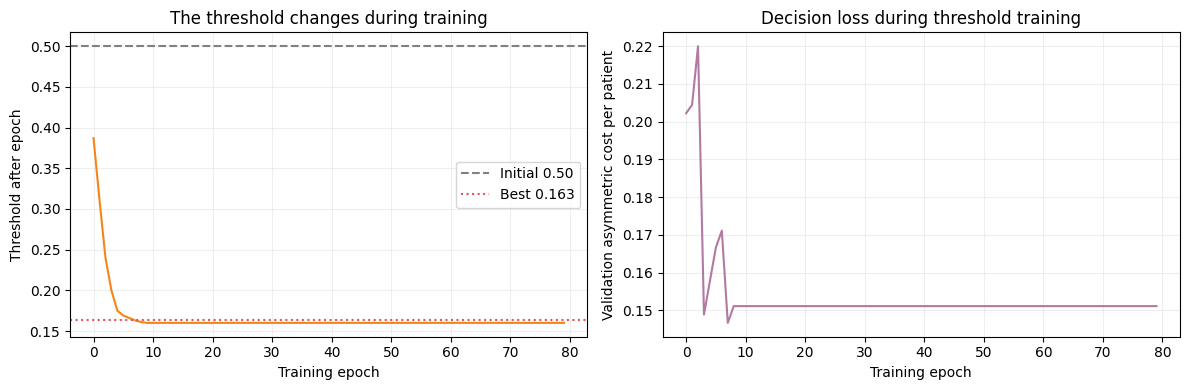

In [23]:
trained_threshold, threshold_history, threshold_loss_history = (
    train_threshold_perceptron(
        y_class_validation,
        validation_probabilities,
        initial_threshold=0.50,
        learning_rate=0.001,
        n_epochs=80,
    )
)
trained_validation_predictions = (
    validation_probabilities >= trained_threshold
).astype(int)

display(pd.DataFrame([
    {
        **scorecard_row("Default threshold 0.50",
                        y_class_validation, default_validation_predictions),
        "threshold": 0.50,
        "asymmetric_cost": asymmetric_decision_loss(
            y_class_validation, default_validation_predictions),
    },
    {
        **scorecard_row("Perceptron-trained threshold",
                        y_class_validation, trained_validation_predictions),
        "threshold": trained_threshold,
        "asymmetric_cost": asymmetric_decision_loss(
            y_class_validation, trained_validation_predictions),
    },
]))

print(f"Perceptron-trained validation threshold: {trained_threshold:.3f}")
print("The logistic weights and bias did not change.")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(threshold_history, color=COLORS["model"])
axes[0].axhline(0.5, linestyle="--", color="gray", label="Initial 0.50")
axes[0].axhline(trained_threshold, linestyle=":", color=COLORS["positive"],
                label=f"Best {trained_threshold:.3f}")
axes[0].set_xlabel("Training epoch")
axes[0].set_ylabel("Threshold after epoch")
axes[0].set_title("The threshold changes during training")
axes[0].legend()
axes[0].grid(alpha=0.2)

axes[1].plot(threshold_loss_history, color=COLORS["validation"])
axes[1].set_xlabel("Training epoch")
axes[1].set_ylabel("Validation asymmetric cost per patient")
axes[1].set_title("Decision loss during threshold training")
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()


> **Reflection**
>
> 1. Why might the clinic prefer the perceptron-trained threshold when the table shows lower accuracy but lower asymmetric cost?
> 2. How do false negatives and false positives move the threshold, including the effect of their unequal costs?
> 3. Why can gradients train logistic-regression weights with BCE but not directly minimize the hard decision loss?


## 6. Honest final evaluation

Data policy:

    training set -> learn weights
    validation set -> select the threshold
    untouched test set -> one final evaluation

The model and threshold are now frozen. We can compare BCE on the training set and final test set to check how well the learned probabilities generalize.


### Compare training and test loss, then evaluate once

The training and final test BCE are shown side by side. After running the next cell, do not tune the model or threshold based on the test results.


In [24]:
final_train_probabilities = sigmoid(
    linear_predict(X_class_train, original_weights, original_bias)
)
final_test_probabilities = sigmoid(
    linear_predict(X_class_test, original_weights, original_bias)
)

train_bce = binary_cross_entropy(y_class_train, final_train_probabilities)
test_bce = binary_cross_entropy(y_class_test, final_test_probabilities)

display(pd.DataFrame({
    "split": ["Training", "Final test"],
    "BCE": [train_bce, test_bce],
}))

final_threshold = trained_threshold
final_test_predictions = (
    final_test_probabilities >= final_threshold
).astype(int)

final_metrics = classification_metrics(y_class_test, final_test_predictions)
final_cost = asymmetric_decision_loss(y_class_test, final_test_predictions)

display(pd.DataFrame([{
    "threshold": final_threshold,
    **final_metrics,
    "asymmetric_cost_per_patient": final_cost,
    "asymmetric_cost_per_1000_patients": 1000 * final_cost,
}]))

print("Comparison number (lower is better):",
      f"{1000 * final_cost:.1f} asymmetric-cost points per 1,000 patients")
print("Also report F2 (higher is better):",
      f"{final_metrics['f2']:.3f}")


,split,BCE
0,Training,0.086
1,Final test,0.103


,threshold,accuracy,precision,recall,f1,f2,asymmetric_cost_per_patient,asymmetric_cost_per_1000_patients
0,0.163,0.931,0.538,0.972,0.693,0.837,0.093,93.126


Comparison number (lower is better): 93.1 asymmetric-cost points per 1,000 patients
Also report F2 (higher is better): 0.837


> **Final reflection**
>
> 1. What does the difference between final-test BCE and training BCE suggest about how well the model generalizes?
> 2. Why is the validation set, rather than the test set, used to train the threshold?
> 3. What are the final asymmetric cost per 1,000 patients and F2 score?

## Finished

You built linear and logistic regression with NumPy, demonstrated the accuracy trap, trained a separate asymmetric-cost threshold with perceptron updates, compared training and test loss, and kept final evaluation honest.
